**EDA Master**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# **1. Bảng products.csv**

In [ ]:
products = pd.read_csv('products.csv')


In [ ]:
products


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406
...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500


In [ ]:
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [ ]:
products.describe()


,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


## Kiểm tra xem size đồ, màu đồ có tính đa dạng không

In [ ]:
size_count = products.groupby(['category','segment','size']).size().reset_index(name='count')
print(size_count)


      category      segment size  count
0       Casual   Activewear    L      8
1       Casual   Activewear    M      8
2       Casual   Activewear    S      8
3       Casual   Activewear   XL      8
4       Casual  All-weather    L     42
5       Casual  All-weather    M     41
6       Casual  All-weather    S     42
7       Casual  All-weather   XL     44
8         GenZ       Trendy    L     38
9         GenZ       Trendy    M     38
10        GenZ       Trendy    S     37
11        GenZ       Trendy   XL     35
12     Outdoor   Activewear    L    141
13     Outdoor   Activewear    M    143
14     Outdoor   Activewear    S    142
15     Outdoor   Activewear   XL    140
16     Outdoor      Premium    L     44
17     Outdoor      Premium    M     44
18     Outdoor      Premium    S     44
19     Outdoor      Premium   XL     45
20  Streetwear     Balanced    L     76
21  Streetwear     Balanced    M     76
22  Streetwear     Balanced    S     77
23  Streetwear     Balanced   XL     77


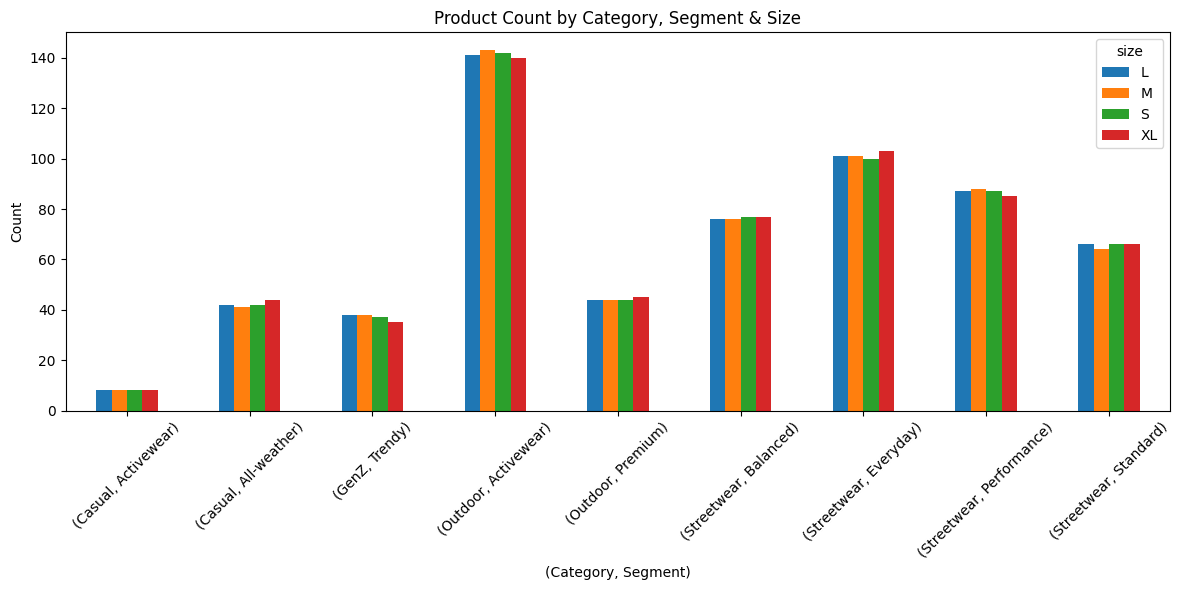

In [ ]:
# pivot
pivot = size_count.pivot_table(
    index=['category','segment'],
    columns='size',
    values='count',
    fill_value=0
)

# plot
pivot.plot(kind='bar', figsize=(12,6))

plt.title('Product Count by Category, Segment & Size')
plt.xlabel('(Category, Segment)')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
pivot


size                        L      M      S     XL
category   segment                                
Casual     Activewear     8.0    8.0    8.0    8.0
           All-weather   42.0   41.0   42.0   44.0
GenZ       Trendy        38.0   38.0   37.0   35.0
Outdoor    Activewear   141.0  143.0  142.0  140.0
           Premium       44.0   44.0   44.0   45.0
Streetwear Balanced      76.0   76.0   77.0   77.0
           Everyday     101.0  101.0  100.0  103.0
           Performance   87.0   88.0   87.0   85.0
           Standard      66.0   64.0   66.0   66.0

## Kiểm tra xem shop này bán nhiều những dạng đồ nào nhất

In [ ]:
category_count = products.groupby('category').size().reset_index(name='count')
print(category_count)


     category  count
0      Casual    201
1        GenZ    148
2     Outdoor    743
3  Streetwear   1320


In [ ]:
segment_count = products.groupby('segment').size().reset_index(name='count')
print(segment_count)


       segment  count
0   Activewear    598
1  All-weather    169
2     Balanced    306
3     Everyday    405
4  Performance    347
5      Premium    177
6     Standard    262
7       Trendy    148


In [ ]:
cat_seg_count = (
    products
    .groupby(['category','segment'])
    .size()
    .reset_index(name='count')
)

print(cat_seg_count)


     category      segment  count
0      Casual   Activewear     32
1      Casual  All-weather    169
2        GenZ       Trendy    148
3     Outdoor   Activewear    566
4     Outdoor      Premium    177
5  Streetwear     Balanced    306
6  Streetwear     Everyday    405
7  Streetwear  Performance    347
8  Streetwear     Standard    262


In [ ]:
pivot = pd.pivot_table(
    products,
    index='category',
    columns='segment',
    aggfunc='size',
    fill_value=0
)
pivot


segment,Activewear,All-weather,Balanced,Everyday,Performance,Premium,Standard,Trendy
category,,,,,,,,
Casual,32,169,0,0,0,0,0,0
GenZ,0,0,0,0,0,0,0,148
Outdoor,566,0,0,0,0,177,0,0
Streetwear,0,0,306,405,347,0,262,0


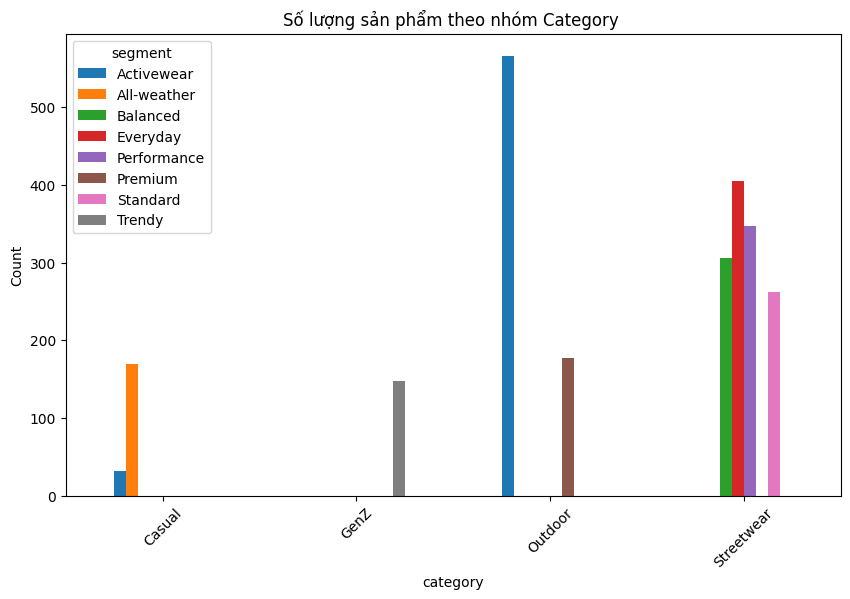

In [ ]:
pivot.plot(kind='bar', figsize=(10,6))
plt.title('Số lượng sản phẩm theo nhóm Category ')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Giả thuyết : Với phân phối về số lượng các sản phẩm thuộc các segment và category như trên, shop này chủ yếu nhắm tới khách hàng có độ tuổi trẻ trung, vì chủ yếu sản phẩm là Outdoor và Streetwear. Ta sẽ kiểm tra giả thuyết này với việc kiểm tra độ tuổi trung bình của khách hàng khi qua tới customers.csv

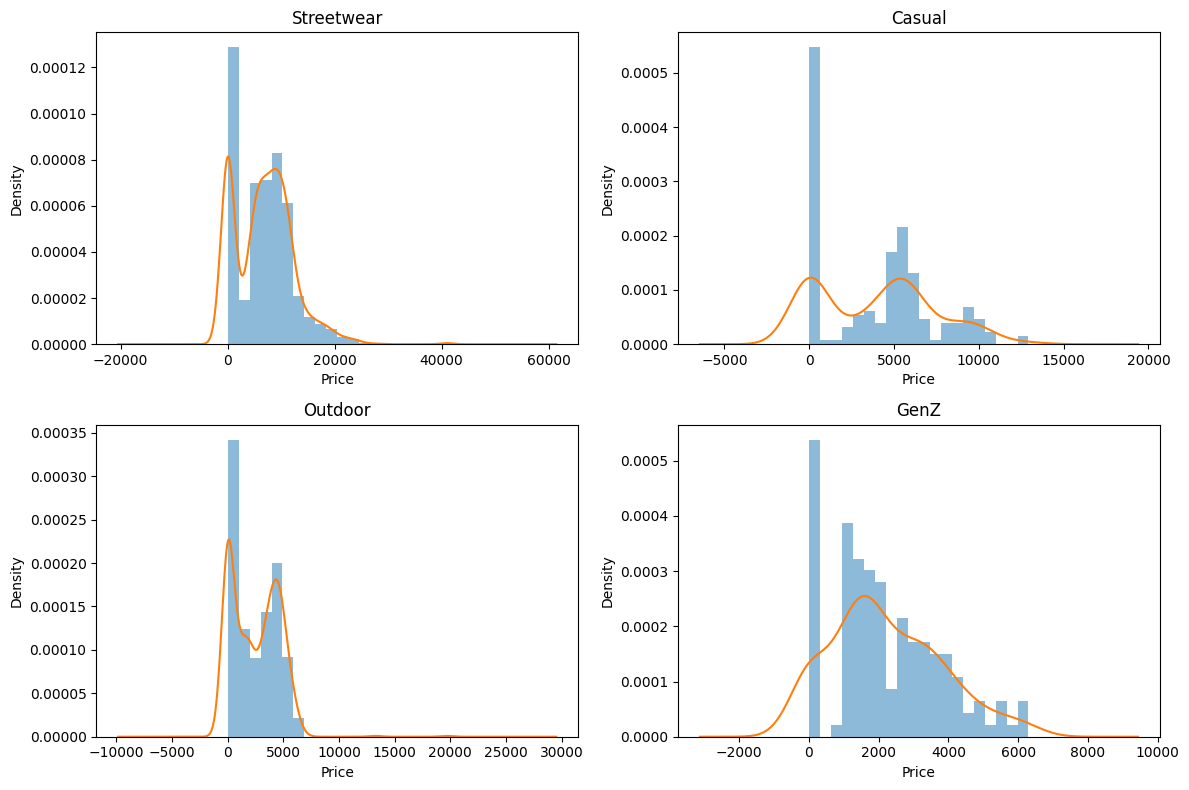

In [ ]:
import math
categories = products['category'].unique()
n = len(categories)

# Tạo grid (vd: 2 cột)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.flatten()  # flatten để loop dễ

for i, cat in enumerate(categories):
    subset = products[products['category'] == cat]
    ax = axes[i]
    
    # Histogram
    ax.hist(subset['price'], bins=20, alpha=0.5, density=True)
    
    # KDE
    subset['price'].plot(kind='kde', ax=ax)
    
    ax.set_title(f'{cat}')
    ax.set_xlabel('Price')
    ax.set_ylabel('Density')

# Ẩn subplot dư (nếu có)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


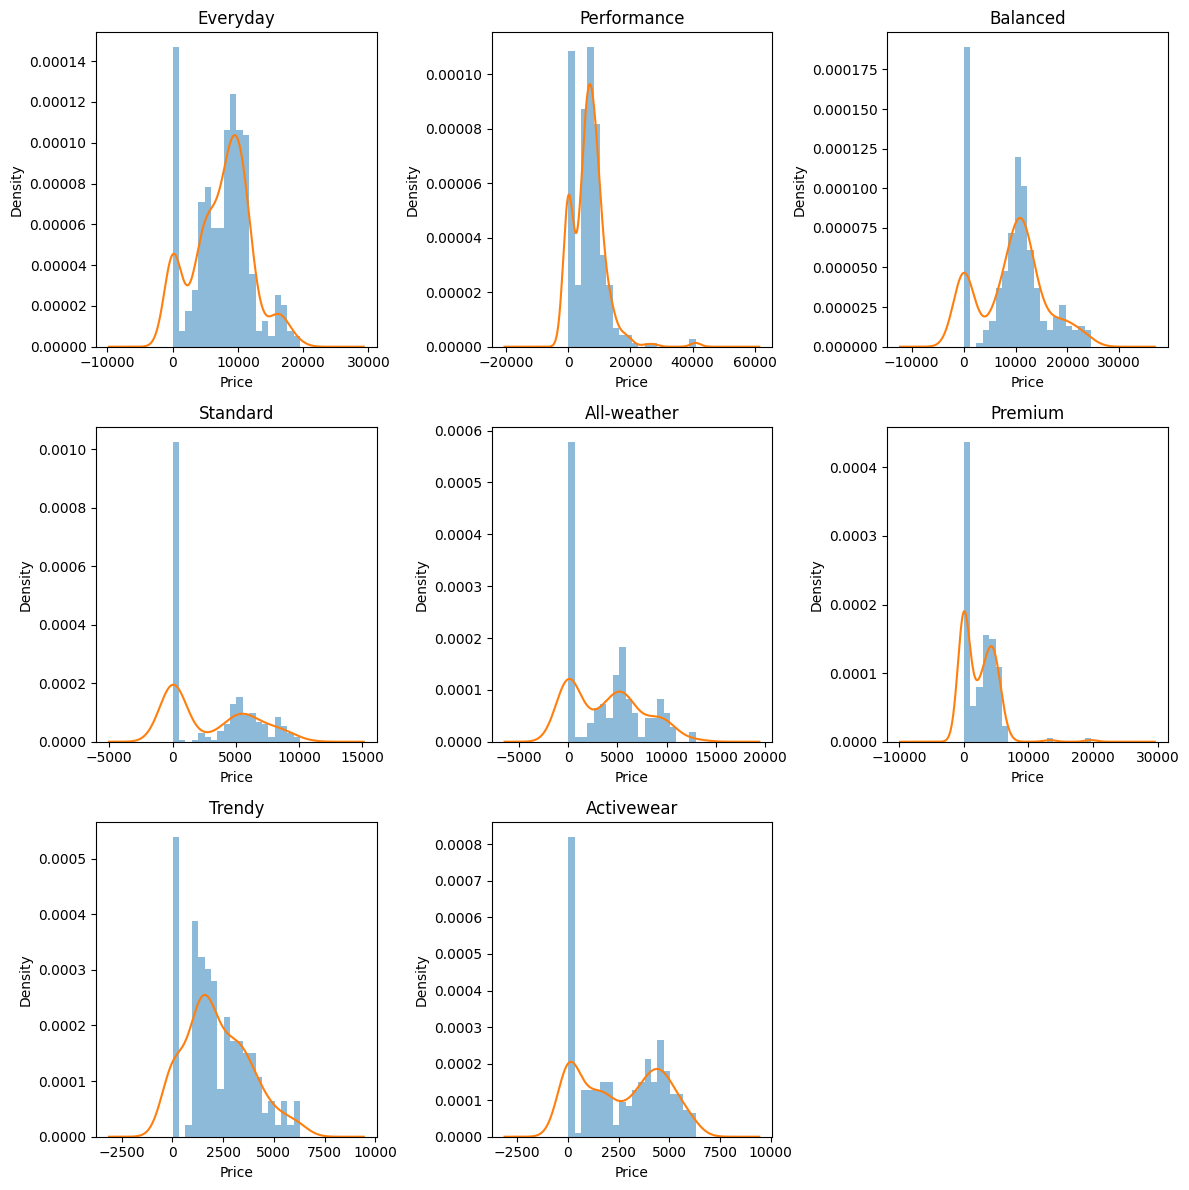

In [ ]:
segments = products['segment'].unique()
n = len(segments)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.flatten()

for i, seg in enumerate(segments):
    subset = products[products['segment'] == seg]
    ax = axes[i]
    
    # Histogram
    ax.hist(subset['price'], bins=20, alpha=0.5, density=True)
    
    # KDE
    subset['price'].plot(kind='kde', ax=ax)
    
    ax.set_title(f'{seg}')
    ax.set_xlabel('Price')
    ax.set_ylabel('Density')

# Ẩn subplot dư
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## *Tạo cột margin : Lợi nhuận*

In [ ]:
df_products = products.copy()


In [ ]:
df_products['margin'] = df_products['price'] - df_products['cogs']


In [ ]:
df_products


,product_id,product_name,category,segment,size,color,price,cogs,margin
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,1354.807125
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,4129.205759
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,4579.713880
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954,7180.544345
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406,1702.764130
...,...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032,2049.406968
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702,1330.215731
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611,299.193822
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500,299.218500


## **Lợi nhuận của việc bán từng 'category'**

Đánh giá chiến lược pricing của shop này

In [ ]:
margin_mean_cat = df_products.groupby('category')['margin'].mean()

print(margin_mean_cat)


category
Casual         882.428874
GenZ           467.457841
Outdoor        518.881732
Streetwear    1457.821320
Name: margin, dtype: float64


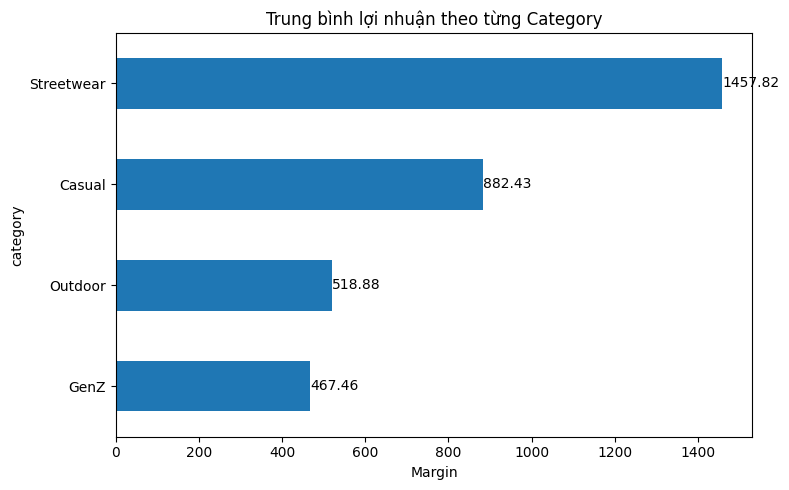

In [ ]:
ax = margin_mean_cat.sort_values().plot(kind='barh', figsize=(8,5))

plt.title('Trung bình lợi nhuận theo từng Category')
plt.xlabel('Margin')

# thêm label lên từng cột
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                va='center')

plt.tight_layout()
plt.show()


## **Lợi nhuận của việc bán từng 'segment'**

In [99]:
margin_mean_seg = df_products.groupby('segment')['margin'].mean()


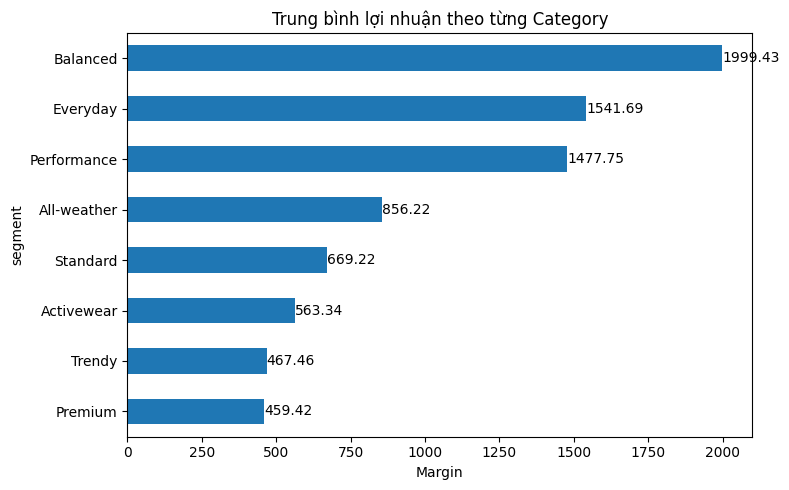

In [ ]:
ax = margin_mean_seg.sort_values().plot(kind='barh', figsize=(8,5))

plt.title('Trung bình lợi nhuận theo từng Category')
plt.xlabel('Margin')

# thêm label lên từng cột
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                va='center')

plt.tight_layout()
plt.show()


# **2. Bảng customers.csv & geography.csv**

In [ ]:
customers = pd.read_csv('customers.csv')


In [ ]:
customers


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search


In [ ]:
customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          121930 non-null  int64 
 1   zip                  121930 non-null  int64 
 2   city                 121930 non-null  object
 3   signup_date          121930 non-null  object
 4   gender               121930 non-null  object
 5   age_group            121930 non-null  object
 6   acquisition_channel  121930 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.5+ MB


In [ ]:
customers['age_group'].unique()


array(['35-44', '45-54', '18-24', '55+', '25-34'], dtype=object)

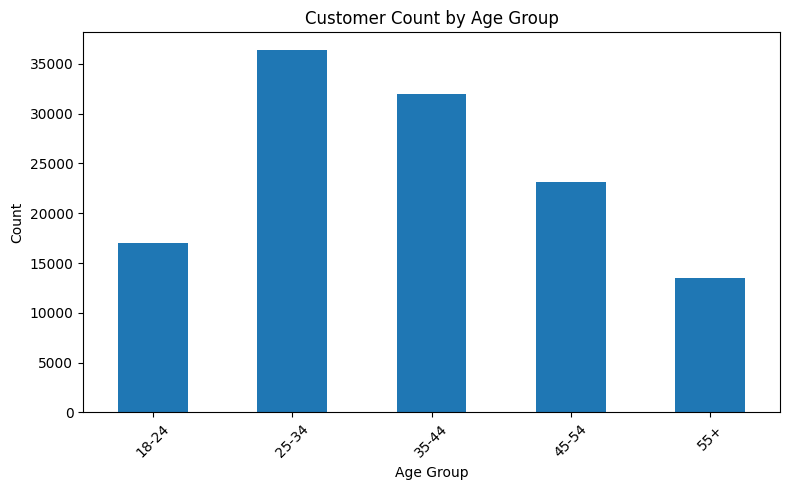

In [ ]:
age_count = customers.groupby('age_group')['customer_id'].size()

age_count.plot(kind='bar', figsize=(8,5))

plt.title('Customer Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Shop Unisex

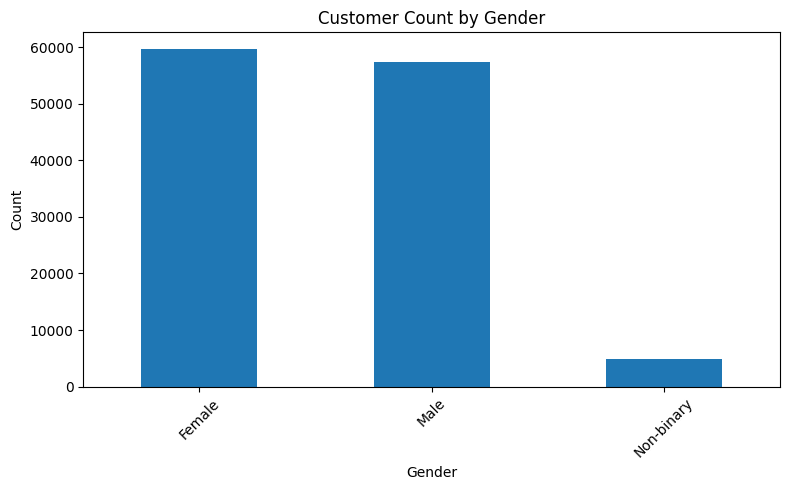

In [ ]:
age_count = customers.groupby('gender')['customer_id'].size()

age_count.plot(kind='bar', figsize=(8,5))

plt.title('Customer Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


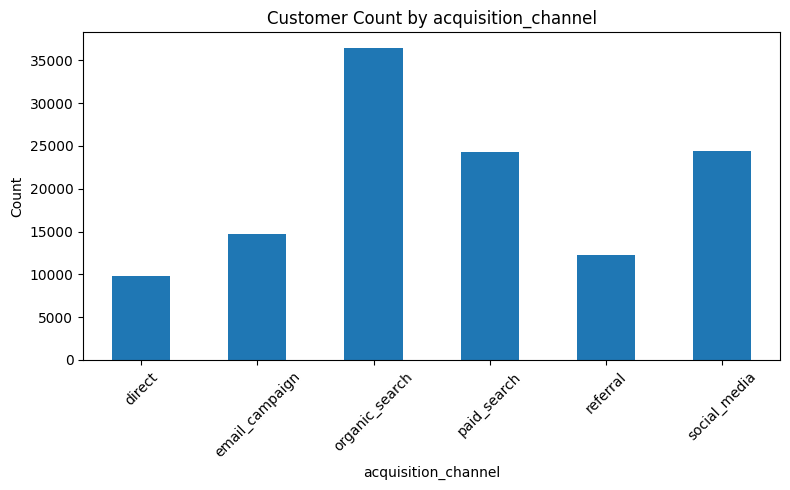

In [ ]:
age_count = customers.groupby('acquisition_channel')['customer_id'].size()

age_count.plot(kind='bar', figsize=(8,5))

plt.title('Customer Count by acquisition_channel')
plt.xlabel('acquisition_channel')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


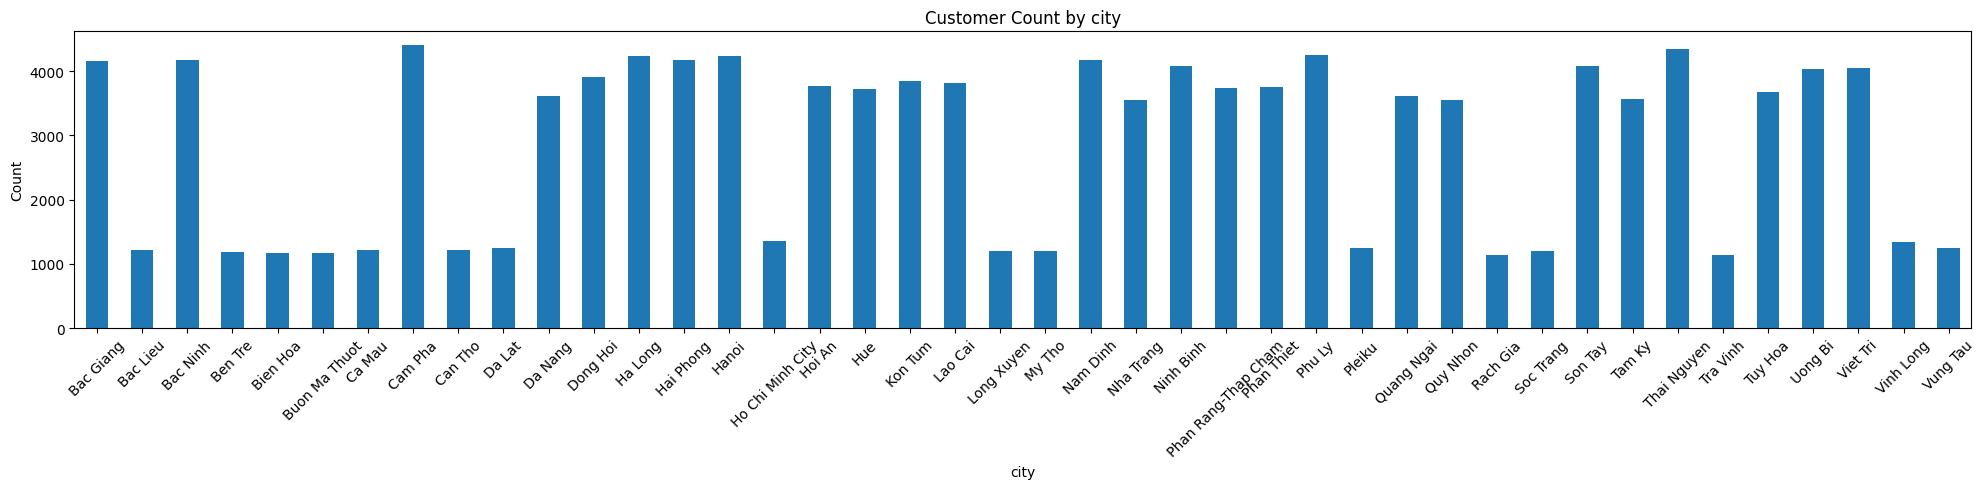

In [ ]:
age_count = customers.groupby('city')['customer_id'].size()

age_count.plot(kind='bar', figsize=(20,5))

plt.title('Customer Count by city')
plt.xlabel('city')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
customers_geo = customers.merge(geography, on='zip', how='left')


In [ ]:
customers_geo


,customer_id,zip,city_x,signup_date,gender,age_group,acquisition_channel,city_y,region,district
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media,Hai Phong,East,District #13
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign,Hai Phong,East,District #13
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search,Hai Phong,East,District #13
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral,Hai Phong,East,District #13
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search,Hai Phong,East,District #13
...,...,...,...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct,Vung Tau,West,District #33
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media,Vung Tau,West,District #33
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral,Vung Tau,West,District #33
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search,Buon Ma Thuot,West,District #33


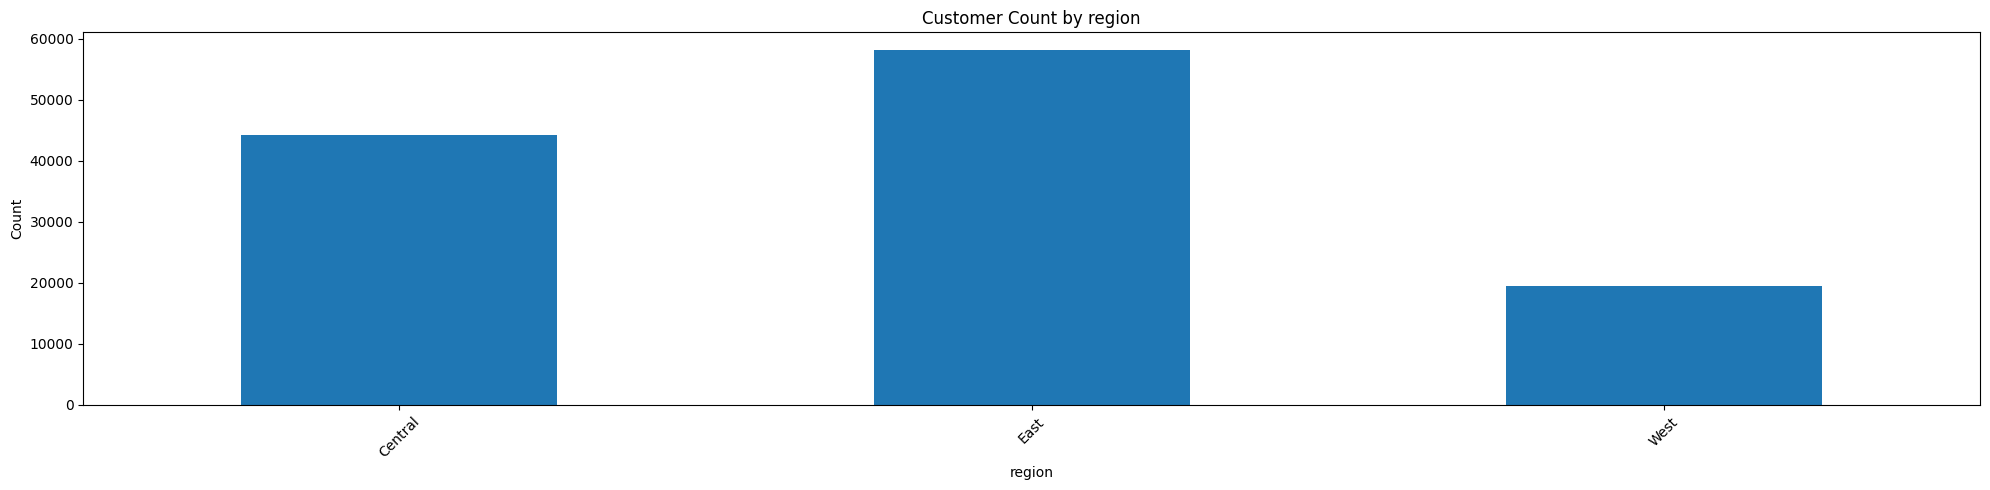

In [ ]:
age_count = customers_geo.groupby('region')['customer_id'].size()

age_count.plot(kind='bar', figsize=(20,5))

plt.title('Customer Count by region')
plt.xlabel('region')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


-> Theo dõi coi là theo từng vùng, thì cái sales bán ra sẽ như thế nào - gộp bảng nào và bảng nào ?

# **3. Bảng promotions.csv**

In [ ]:
promotions = pd.read_csv('promotions.csv')


In [ ]:
promotions


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
6,PROMO-0007,Spring Sale 2014,percentage,12.0,2014-03-18,2014-04-17,NaN,email,1,0
7,PROMO-0008,Mid-Year Sale 2014,percentage,18.0,2014-06-23,2014-07-22,NaN,social_media,0,0
8,PROMO-0009,Fall Launch 2014,percentage,10.0,2014-08-30,2014-10-01,NaN,all_channels,0,100000
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,2014-11-19,2015-01-02,NaN,all_channels,0,100000


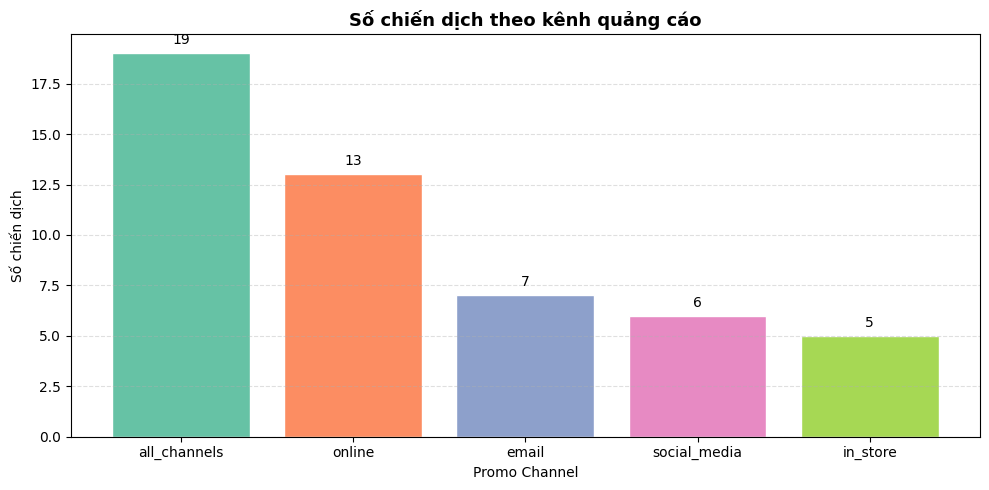

In [ ]:
channel_counts = df_promo['promo_channel'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    channel_counts.index,
    channel_counts.values,
    color=plt.cm.Set2.colors[:len(channel_counts)],
    edgecolor='white'
)

# Label số lượng trên mỗi cột
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=10
    )

ax.set_xlabel('Promo Channel')
ax.set_ylabel('Số chiến dịch')
ax.set_title('Số chiến dịch theo kênh quảng cáo', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('promo_channel_histogram.png', dpi=150)
plt.show()


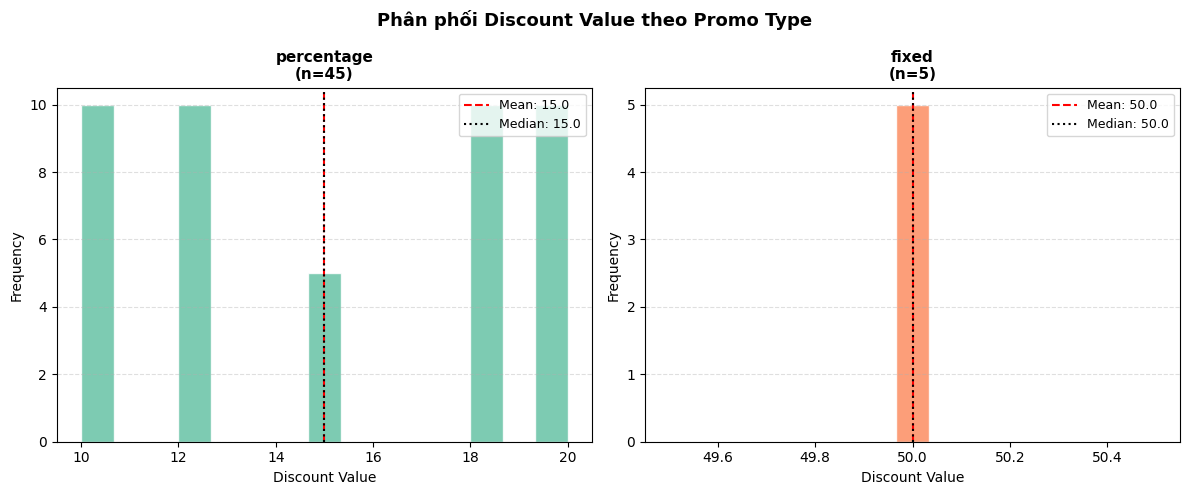

In [ ]:
promo_types = df_promo['promo_type'].unique()
colors = plt.cm.Set2.colors

fig, axes = plt.subplots(1, len(promo_types), figsize=(6 * len(promo_types), 5), sharey=False)

if len(promo_types) == 1:
    axes = [axes]

for ax, (ptype, color) in zip(axes, zip(promo_types, colors)):
    data = df_promo[df_promo['promo_type'] == ptype]['discount_value'].dropna()

    ax.hist(data, bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='black', linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.1f}')

    ax.set_title(f'{ptype}\n(n={len(data)})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Discount Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Phân phối Discount Value theo Promo Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('discount_by_promo_type.png', dpi=150)
plt.show()


In [1]:
import pandas as pd


In [5]:
orders = pd.read_csv('../../orders.csv')
customers = pd.read_csv('../../customers.csv')
orders_items = pd.read_csv('../../order_items.csv')


/var/folders/36/khn_y8zn7qqflczfpst8cbfc0000gn/T/ipykernel_11730/1335698365.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  orders_items = pd.read_csv('../../order_items.csv')


In [ ]:
detail_orders = orders.join(orders_items.set_index('order_id'), on='order_id', how='left')
detail_orders


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,1138.22,0.0,NaN,NaN
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,10166.25,0.0,NaN,NaN
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,11220.33,0.0,NaN,NaN
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,10639.25,0.0,NaN,NaN
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,1597.84,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646940,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,4473.92,0.0,NaN,NaN
646941,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,5250.79,0.0,NaN,NaN
646942,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,7389.06,0.0,NaN,NaN
646943,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,4767.33,0.0,NaN,NaN


In [7]:
detail_orders_customers = detail_orders.merge(customers, on='customer_id', how='left')  
detail_orders_customers


,order_id,order_date,customer_id,zip_x,order_status,payment_method,device_type,order_source,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,zip_y,city,signup_date,gender,age_group,acquisition_channel
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,1138.22,0.0,NaN,NaN,1109,Hanoi,2020-06-06,Female,35-44,social_media
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,10166.25,0.0,NaN,NaN,1330,Phu Ly,2021-11-03,Female,18-24,social_media
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,11220.33,0.0,NaN,NaN,1473,Lao Cai,2020-09-18,Female,35-44,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,10639.25,0.0,NaN,NaN,2360,Son Tay,2016-05-29,Male,45-54,direct
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,1597.84,0.0,NaN,NaN,2886,Uong Bi,2017-07-11,Male,18-24,social_media
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,4473.92,0.0,NaN,NaN,33907,Bac Ninh,2018-10-16,Male,18-24,paid_search
714665,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,5250.79,0.0,NaN,NaN,37091,Ha Long,2022-11-12,Male,45-54,organic_search
714666,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,7389.06,0.0,NaN,NaN,80516,Kon Tum,2022-01-02,Male,45-54,organic_search
714667,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,4767.33,0.0,NaN,NaN,93510,Ben Tre,2021-06-12,Male,25-34,referral


In [79]:
detail_orders_customers['total'] = (
    detail_orders_customers['unit_price'] * detail_orders_customers['quantity']
)

result = detail_orders_customers.groupby('order_id')['total'].sum()


In [80]:
result


order_id
1          7967.54
2         71163.75
3         33660.99
4         53196.25
6          1597.84
            ...   
834372    35791.36
834377    36755.53
834387    59112.48
834392    23836.65
834397     4716.75
Name: total, Length: 646945, dtype: float64

In [81]:
result = pd.DataFrame(result).merge(orders[['order_id','customer_id','order_date']], on='order_id', how='left')
result


,order_id,total,customer_id,order_date
0,1,7967.54,58578,2012-07-04
1,2,71163.75,58621,2012-07-04
2,3,33660.99,58811,2012-07-04
3,4,53196.25,59453,2012-07-04
4,6,1597.84,57821,2012-07-06
...,...,...,...,...
646940,834372,35791.36,19490,2022-12-31
646941,834377,36755.53,73046,2022-12-31
646942,834387,59112.48,107723,2022-12-31
646943,834392,23836.65,139431,2022-12-31


In [82]:
result = pd.DataFrame(result).merge(customers[['customer_id','acquisition_channel','gender']], on='customer_id', how='left')
result


,order_id,total,customer_id,order_date,acquisition_channel,gender
0,1,7967.54,58578,2012-07-04,social_media,Female
1,2,71163.75,58621,2012-07-04,social_media,Female
2,3,33660.99,58811,2012-07-04,direct,Female
3,4,53196.25,59453,2012-07-04,direct,Male
4,6,1597.84,57821,2012-07-06,social_media,Male
...,...,...,...,...,...,...
646940,834372,35791.36,19490,2022-12-31,paid_search,Male
646941,834377,36755.53,73046,2022-12-31,organic_search,Male
646942,834387,59112.48,107723,2022-12-31,organic_search,Male
646943,834392,23836.65,139431,2022-12-31,referral,Male


In [83]:
result.columns


Index(['order_id', 'total', 'customer_id', 'order_date', 'acquisition_channel',
       'gender'],
      dtype='object')

In [86]:
result['order_date'] = pd.to_datetime(result['order_date'])


In [87]:
daily_age = result.groupby(
    [result['order_date'].dt.date, 'gender']
)['total'].sum().reset_index()


In [88]:
pivot_table = daily_age.pivot(
    index='order_date',
    columns='gender',  
    values='total'
).fillna(0)


In [89]:
pivot_table


gender,Female,Male,Non-binary
order_date,,,
2012-07-04,2618443.38,2240099.50,265005.06
2012-07-05,1038228.01,1700148.58,13396.86
2012-07-06,1461203.04,1365922.07,226904.31
2012-07-07,1616464.65,1018698.62,32767.67
2012-07-08,1051493.80,1216462.70,92895.40
...,...,...,...
2022-12-27,1087176.90,951200.00,62176.76
2022-12-28,1629737.21,1673788.74,145203.25
2022-12-29,1361896.80,1652537.99,69509.54


In [ ]:
pivot_table[pivot_table['order_date'] == '2012-07-04']


KeyError: 'order_date'

array([[<Axes: xlabel='order_date'>, <Axes: xlabel='order_date'>],
       [<Axes: xlabel='order_date'>, <Axes: xlabel='order_date'>]],
      dtype=object)

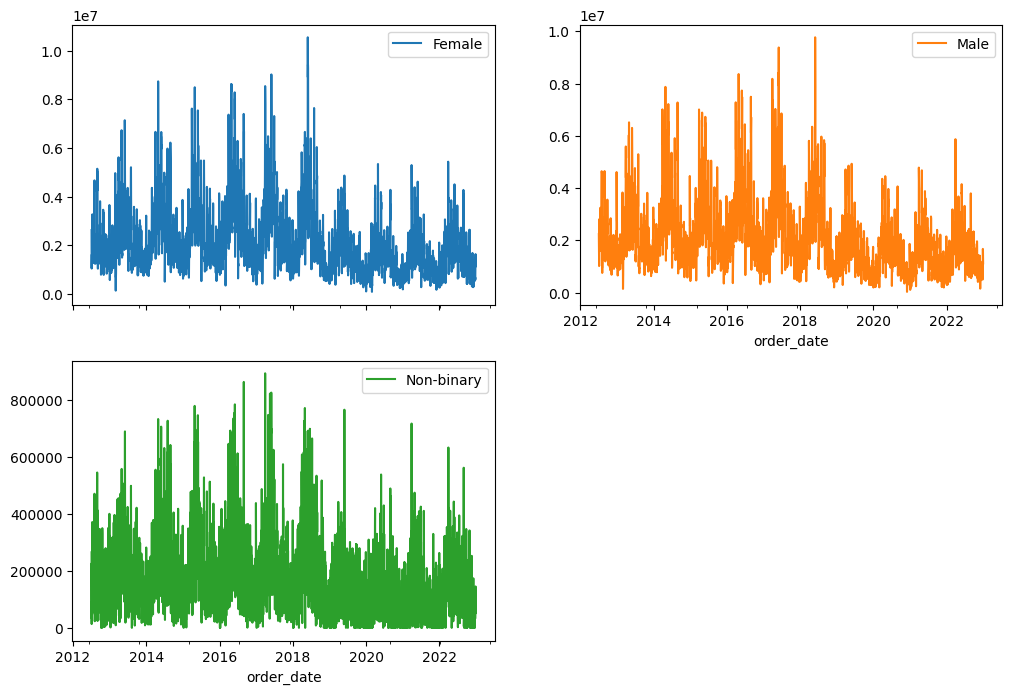

In [90]:
import math

n_cols = 2
n_rows = math.ceil(len(pivot_table.columns) / n_cols)

pivot_table.plot(
    subplots=True,
    layout=(n_rows, n_cols),
    figsize=(12, 4 * n_rows),
    sharex=True
)


In [91]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    # Copied from https://machinelearningmastery.com/time-series-data-stationary-python/

    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")


In [92]:
for col in pivot_table.columns:
    if col == 'order_date':
        continue
    print(f"Checking stationarity for {col}:")
    check_stationarity(pivot_table[col])
    print("\n")


Checking stationarity for Female:
ADF Statistic: -2.466738
p-value: 0.123779
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Non-stationary


Checking stationarity for Male:
ADF Statistic: -2.520213
p-value: 0.110633
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Non-stationary


Checking stationarity for Non-binary:
ADF Statistic: -3.229741
p-value: 0.018326
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Stationary




In [75]:
detail_orders_customers[detail_orders_customers['order_date'] == '2012-07-04'].shape


(174, 21)

In [76]:
detail_orders_customers[detail_orders_customers['order_date'] == '2012-07-04']['total'].sum()


np.float64(5123547.9399999995)